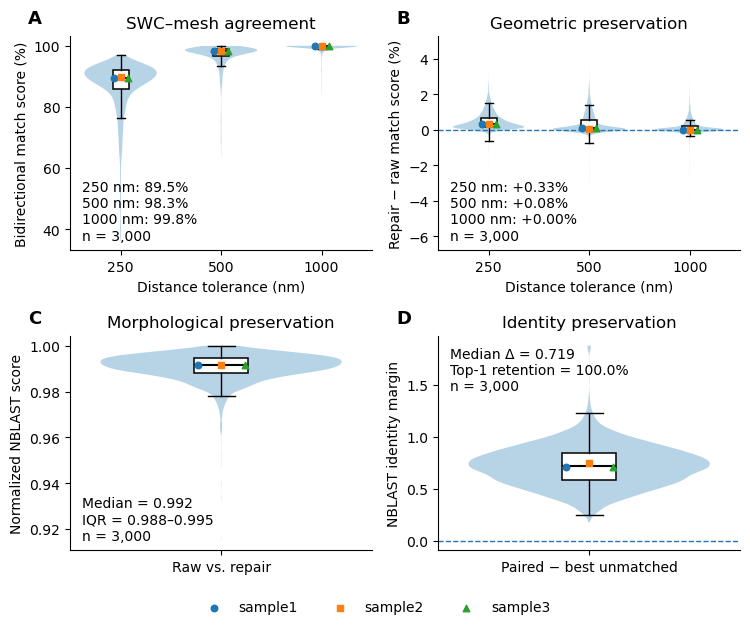

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path("/data/project_backup/swc_fix")
samples = ["sample1", "sample2", "sample3"]
ths = [250, 500, 1000]
markers = ["o", "s", "^"]
offsets = [-.07, 0, .07]

# =========================
# Load
# =========================
mesh, nb = [], []

for s in samples:
    root = base/s
    raw = pd.read_csv(root/"mesh_match_summary_raw.csv", dtype={"root_id": str})
    rep = pd.read_csv(root/"mesh_match_summary_repair.csv", dtype={"root_id": str})
    n = pd.read_csv(root/"nblast_summary_clean.csv")

    raw = raw[raw["scope"].eq("all")]
    rep = rep[rep["scope"].eq("all")]

    cols = ["root_id"] + [f"match_score_{t}nm" for t in ths]
    d = rep[cols].merge(raw[cols], on="root_id", suffixes=("_repair", "_raw"))
    d["sample"] = s

    for t in ths:
        d[f"delta_{t}"] = d[f"match_score_{t}nm_repair"] - d[f"match_score_{t}nm_raw"]

    n["sample"] = s
    mesh.append(d)
    nb.append(n)

mesh = pd.concat(mesh, ignore_index=True)
nb = pd.concat(nb, ignore_index=True)

to_bool = lambda x: x.astype(str).str.lower().isin(["true", "1"])


# =========================
# Helpers
# =========================
def violin_box(ax, data, pos):
    v = ax.violinplot(data, pos, widths=.72, showextrema=False)
    for b in v["bodies"]:
        b.set_alpha(.32)

    ax.boxplot(
        data, positions=pos, widths=.16, patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="white", linewidth=1.1),
        medianprops=dict(color="black", linewidth=1.5),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0)
    )


def add_sample_medians(ax, cols, positions):
    handles = []
    for i, s in enumerate(samples):
        y = [mesh.loc[mesh["sample"].eq(s), c].median() for c in cols]
        h = ax.scatter(
            np.array(positions) + offsets[i], y,
            marker=markers[i], s=22, zorder=5, label=s
        )
        handles.append(h)
    return handles


# =========================
# Figure
# =========================
fig, ax = plt.subplots(2, 2, figsize=(7.6, 6.3))
ax = ax.ravel()

# ---------- A ----------
cols = [f"match_score_{t}nm_repair" for t in ths]
data = [mesh[c].dropna() for c in cols]

violin_box(ax[0], data, [1, 2, 3])
handles = add_sample_medians(ax[0], cols, [1, 2, 3])

ax[0].set(
    xticks=[1, 2, 3],
    xticklabels=["250", "500", "1000"],
    xlabel="Distance tolerance (nm)",
    ylabel="Bidirectional match score (%)",
    title="SWC–mesh agreement"
)
ax[0].text(
    .04, .05,
    "\n".join(f"{t} nm: {x.median():.1f}%" for t, x in zip(ths, data))
    + f"\nn = {len(mesh):,}",
    transform=ax[0].transAxes
)

# ---------- B ----------
cols = [f"delta_{t}" for t in ths]
data = [mesh[c].dropna() for c in cols]

violin_box(ax[1], data, [1, 2, 3])
add_sample_medians(ax[1], cols, [1, 2, 3])
ax[1].axhline(0, ls="--", lw=1)

ax[1].set(
    xticks=[1, 2, 3],
    xticklabels=["250", "500", "1000"],
    xlabel="Distance tolerance (nm)",
    ylabel="Repair − raw match score (%)",
    title="Geometric preservation"
)
ax[1].text(
    .04, .05,
    "\n".join(f"{t} nm: {x.median():+.2f}%" for t, x in zip(ths, data))
    + f"\nn = {len(mesh):,}",
    transform=ax[1].transAxes
)

# ---------- C ----------
paired = nb["paired_nblast_score"].dropna()

violin_box(ax[2], [paired], [1])

for i, s in enumerate(samples):
    y = nb.loc[nb["sample"].eq(s), "paired_nblast_score"].median()
    ax[2].scatter(1 + offsets[i], y, marker=markers[i], s=22, zorder=5)

q1, q3 = paired.quantile([.25, .75])

ax[2].set(
    xlim=(.55, 1.45),
    xticks=[1],
    xticklabels=["Raw vs. repair"],
    ylabel="Normalized NBLAST score",
    title="Morphological preservation"
)
ax[2].text(
    .04, .05,
    f"Median = {paired.median():.3f}\n"
    f"IQR = {q1:.3f}–{q3:.3f}\n"
    f"n = {len(paired):,}",
    transform=ax[2].transAxes
)

# ---------- D ----------
delta = nb["delta_nblast"].dropna()

violin_box(ax[3], [delta], [1])
ax[3].axhline(0, ls="--", lw=1)

for i, s in enumerate(samples):
    y = nb.loc[nb["sample"].eq(s), "delta_nblast"].median()
    ax[3].scatter(1 + offsets[i], y, marker=markers[i], s=22, zorder=5)

acc = to_bool(nb["top1_is_same_name"]).mean() * 100

ax[3].set(
    xlim=(.55, 1.45),
    xticks=[1],
    xticklabels=["Paired − best unmatched"],
    ylabel="NBLAST identity margin",
    title="Identity preservation"
)
ax[3].text(
    .04, .95,
    f"Median Δ = {delta.median():.3f}\n"
    f"Top-1 retention = {acc:.1f}%\n"
    f"n = {len(delta):,}",
    transform=ax[3].transAxes, va="top"
)

# =========================
# Style
# =========================
for i, a in enumerate(ax):
    a.spines[["top", "right"]].set_visible(False)
    a.tick_params(direction="out")
    a.text(
        -.14, 1.06, chr(65+i),
        transform=a.transAxes,
        fontsize=13, fontweight="bold"
    )

fig.legend(
    handles, samples,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(.5, -.005)
)

plt.tight_layout(rect=[0, .055, 1, 1])

plt.savefig(base/"repair_validation_main.pdf", bbox_inches="tight")
plt.savefig(base/"repair_validation_main.png", dpi=600, bbox_inches="tight")
plt.show()